<a href="https://colab.research.google.com/github/Valentin-Grachev/ML-2025/blob/master/StudentExamScores_HW7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd # работа с табличными данными
import numpy as np  # численные операции и массивы

from sklearn.preprocessing import StandardScaler   # стандартизация признаков
from sklearn.decomposition import PCA              # понижение размерности (PCA)
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering  # алгоритмы кластеризации
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score  # метрики сравнения кластеров с истинными метками

import matplotlib.pyplot as plt   # построение графиков
import seaborn as sns             # визуализация данных


In [8]:
url = "https://raw.githubusercontent.com/Valentin-Grachev/ML-2025/master/dataset.csv"

## 1. Описание задачи

Решить задачу кластеризации с использованием методов обучения без учителя KMeans, DBSCAN и Agglomerative Clustering.
Для визуализации результатов применить метод понижения размерности PCA.
Сравнить полученные кластеры с истинными метками классов и сделать выводы.

## 2. Подготовка данных

In [95]:
# Загрузка данных
data = pd.read_csv(url)

# В прошлой работе говорилось, что предсказываем только оценку за экзамен по математике без использования знаний об оценках по другим предметам
data.drop('WritingScore', axis= 1 , inplace= True )
data.drop('ReadingScore', axis= 1 , inplace= True )

# В первом столбце неизвестные некорректные данные, удалим столбец
data = data.drop(data.columns[0], axis=1)


# Заполнение пропущенных признаков модой
modes = data.mode()
for colname in data.columns:
  data[colname] = data[colname].fillna(modes[colname][0])

# Обработка категориальных признаков
categr_cols = ['Gender', 'EthnicGroup', 'ParentEduc', 'LunchType',
'TestPrep', 'ParentMaritalStatus', 'PracticeSport', 'IsFirstChild', 'TransportMeans', 'WklyStudyHours']

selected_categ_cols = ['Gender', 'EthnicGroup', 'ParentEduc', 'LunchType',
'TestPrep', 'ParentMaritalStatus', 'PracticeSport', 'IsFirstChild', 'TransportMeans', 'WklyStudyHours']

for category in categr_cols:
  data[category] = data[category].astype('category')

# Нормализация числовых признаков
data[['MathScore']] = data[['MathScore']] / 100.0
data[['NrSiblings']] = data[['NrSiblings']] / data[['NrSiblings']].max()

# data = data[['Gender', 'WklyStudyHours', 'NrSiblings', 'MathScore']].copy()

data.head()

,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,ParentMaritalStatus,PracticeSport,IsFirstChild,NrSiblings,TransportMeans,WklyStudyHours,MathScore
0,female,group C,bachelor's degree,standard,none,married,regularly,yes,0.428571,school_bus,< 5,0.71
1,female,group C,some college,standard,none,married,sometimes,yes,0.000000,school_bus,5 - 10,0.69
2,female,group B,master's degree,standard,none,single,sometimes,yes,0.571429,school_bus,< 5,0.87
3,male,group A,associate's degree,free/reduced,none,married,never,no,0.142857,school_bus,5 - 10,0.45
4,male,group C,some college,standard,none,married,sometimes,yes,0.000000,school_bus,5 - 10,0.76


In [96]:
# Бинаризация категориальных признаков
from sklearn.preprocessing import OneHotEncoder
enc = OneHotEncoder(drop='first', sparse_output=False)
enc.fit(data[selected_categ_cols])

dummies = pd.DataFrame(enc.transform(data[selected_categ_cols]), columns=enc.get_feature_names_out(), index=data.index)
data = pd.concat((data, dummies), axis=1).drop(selected_categ_cols, axis=1)

data.head()

,NrSiblings,MathScore,Gender_male,EthnicGroup_group B,EthnicGroup_group C,EthnicGroup_group D,EthnicGroup_group E,ParentEduc_bachelor's degree,ParentEduc_high school,ParentEduc_master's degree,...,TestPrep_none,ParentMaritalStatus_married,ParentMaritalStatus_single,ParentMaritalStatus_widowed,PracticeSport_regularly,PracticeSport_sometimes,IsFirstChild_yes,TransportMeans_school_bus,WklyStudyHours_< 5,WklyStudyHours_> 10
0,0.428571,0.71,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,1.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0
1,0.000000,0.69,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0
2,0.571429,0.87,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0
3,0.142857,0.45,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.000000,0.76,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0


## 3. Визуализация РСА-проекции

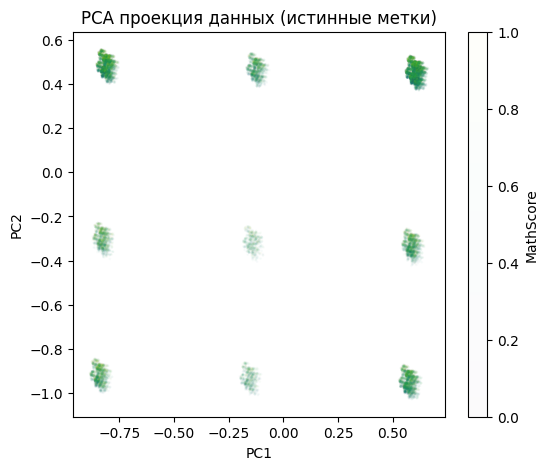

In [105]:
# Истинные метки
y_true = data['MathScore']

# Данные для кластеризации
X = data.drop(columns=['MathScore'])

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(6, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_true, cmap='viridis', s=1, alpha=0.02)
plt.title("PCA проекция данных (истинные метки)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label='MathScore')
plt.show()

## 4. Запуск методов кластеризации

In [98]:
sample_size = 5000
X_sample = X[:sample_size]
y_sample = y_true[:sample_size]
X_pca_sample = X_pca[:sample_size]

# 1. KMeans
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(X_sample)

# 2. DBSCAN
dbscan = DBSCAN(eps=1.5, min_samples=10)
labels_dbscan = dbscan.fit_predict(X_sample)

# 3. Иерархическая кластеризация (Agglomerative)
agglo = AgglomerativeClustering(n_clusters=2)
labels_agglo = agglo.fit_predict(X_sample)

Text(0.5, 1.0, 'Agglomerative (Sample)')

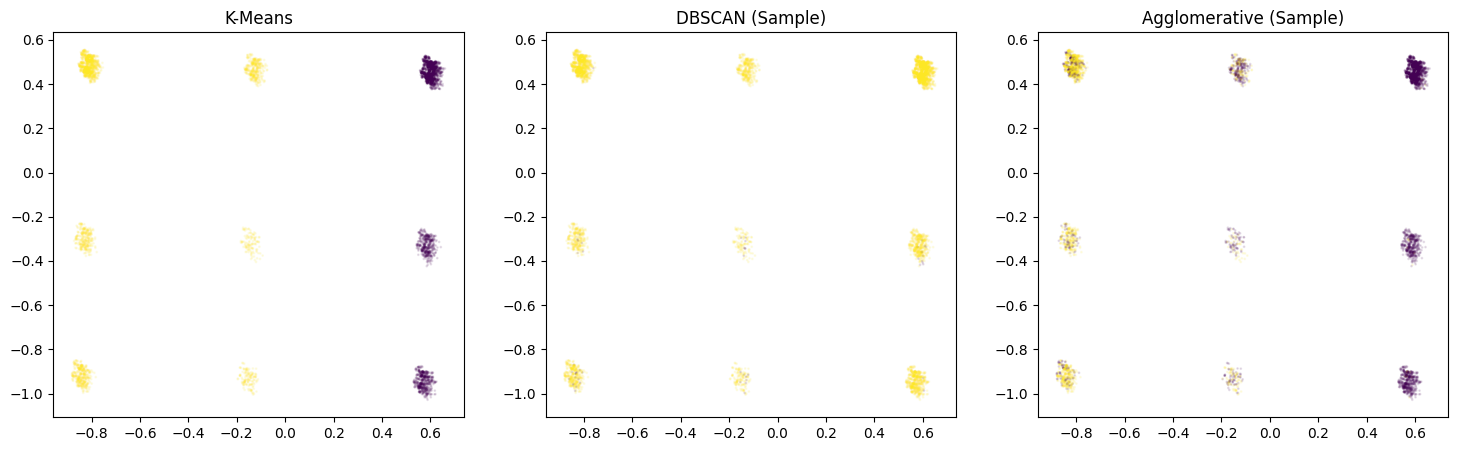

In [108]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(X_pca_sample[:, 0], X_pca_sample[:, 1], c=labels_kmeans, cmap='viridis', s=1, alpha=0.1)
axes[0].set_title('K-Means')

axes[1].scatter(X_pca_sample[:, 0], X_pca_sample[:, 1], c=labels_dbscan, cmap='viridis', s=1, alpha=0.1)
axes[1].set_title('DBSCAN (Sample)')

axes[2].scatter(X_pca_sample[:, 0], X_pca_sample[:, 1], c=labels_agglo, cmap='viridis', s=1, alpha=0.1)
axes[2].set_title('Agglomerative (Sample)')

In [114]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

def print_clustering_metrics(X, labels, name):
    print(f"--- Метрики для {name} ---")

    # (-1, 1) - Насколько точка ближе к своему кластеру, чем к соседнему
    if len(np.unique(labels)) > 1:
        silhouette = silhouette_score(X, labels)
        print(f"Silhouette Score: {silhouette:.4f}")

    # Сравнивнение расстояния между кластерами с расстоянием внутри кластеров
    ch_score = calinski_harabasz_score(X, labels)
    print(f"Calinski-Harabasz: {ch_score:.4f}")

    # Средняя похожесть каждого кластера на самый похожий соседний
    db_score = davies_bouldin_score(X, labels)
    print(f"Davies-Bouldin: {db_score:.4f}")

    # Средний MathScore по кластерам
    for cluster in np.unique(labels):
        if cluster != -1:  # не шум
            mask = labels == cluster
            avg_math = y_sample[mask].mean() if hasattr(y_sample, 'mean') else np.mean(y_sample[mask])
            print(f"  Кластер {cluster}: {sum(mask)} точек, средний MathScore: {avg_math:.3f}")

    print("-" * 30)

print_clustering_metrics(X_sample, labels_kmeans, "K-Means")
print_clustering_metrics(X_sample, labels_dbscan, "DBSCAN")
print_clustering_metrics(X_sample, labels_agglo, "Agglomerative")

--- Метрики для K-Means ---
Silhouette Score: 0.1006
Calinski-Harabasz: 563.7273
Davies-Bouldin: 2.9628
  Кластер 0: 2606 точек, средний MathScore: 0.665
  Кластер 1: 2394 точек, средний MathScore: 0.663
------------------------------
--- Метрики для DBSCAN ---
Silhouette Score: 0.0885
Calinski-Harabasz: 16.4603
Davies-Bouldin: 3.5524
  Кластер 0: 4949 точек, средний MathScore: 0.664
------------------------------
--- Метрики для Agglomerative ---
Silhouette Score: 0.0751
Calinski-Harabasz: 384.0086
Davies-Bouldin: 3.4010
  Кластер 0: 3268 точек, средний MathScore: 0.672
  Кластер 1: 1732 точек, средний MathScore: 0.649
------------------------------


## 5. Вывод
Методы кластеризации (K-Means, DBSCAN, иерархическая) не нашли в данных чётких групп, связанных с оценками по математике. Средние баллы во всех найденных кластерах почти одинаковы. Метрики качества кластеризации показывают слабую и неоднозначную структуру.

PCA-визуализация для таких данных плохо подходит, потому что много категориальных признаков после кодирования создают на графике искусственные группы, которые не имеют смысла.

Из трёх методов K-Means справился немного лучше других по метрикам, но все методы не смогли выделить группы студентов с разной успеваемостью.